In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.linalg import eigh
from qiskit.quantum_info import SparsePauliOp,Statevector
from qiskit.circuit.library import EfficientSU2,TwoLocal
from qiskit.primitives import StatevectorEstimator,StatevectorSampler
from qiskit_algorithms import VQE, VQD
from qiskit.circuit.library import n_local
from qiskit_algorithms.optimizers import COBYLA
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_algorithms.state_fidelities import ComputeUncompute
import time
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [2]:
def build_tfim(n, J, h):
    terms = []
    for i in range(n - 1):
        z = ["I"] * n
        z[i] = "Z"
        z[i + 1] = "Z"
        terms.append(("".join(z), -J))
    for i in range(n):
        x = ["I"] * n
        x[i] = "X"
        terms.append(("".join(x), -h))
    return SparsePauliOp.from_list(terms)

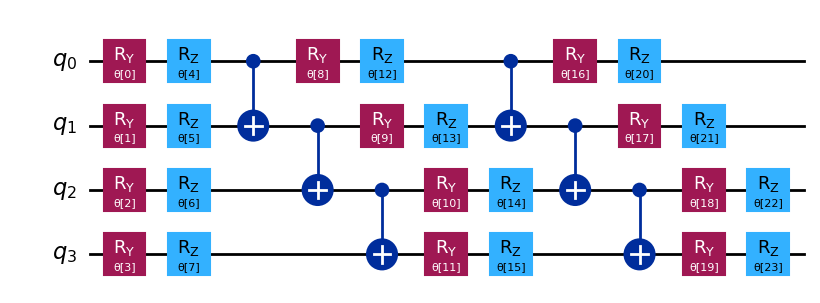

In [3]:
def tfim_ansatz(n,reps=2, entanglement="linear"):
    return TwoLocal(
        n,
        rotation_blocks=['ry','rz'],
        entanglement_blocks='cx',
        entanglement=entanglement,
        reps=reps
    )
ansatz = tfim_ansatz(4, reps=2, entanglement="linear")
optimizer = COBYLA(
    maxiter=300,
    tol=1e-6
)
ansatz.decompose().draw("mpl")

In [5]:
#1
def VQE_ground_energy(H, n,reps,entanglement):
    energies = []
    def callback(eval_count, params, energy, metadata):
        energies.append(energy)
    ansatz = tfim_ansatz(n, reps=reps, entanglement=entanglement)
    estimator = StatevectorEstimator()
    optimizer = COBYLA(maxiter=500)
    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer,
        callback=callback
    )
    result = vqe.compute_minimum_eigenvalue(H)
    return energies, result.eigenvalue.real

In [6]:
#2
def VQD_excited_n_energy(H,n,state,reps,entanglement):
    ansatz = tfim_ansatz(n,reps=reps, entanglement=entanglement)
    optimizer = COBYLA(maxiter=500)
    estimator = StatevectorEstimator()
    sampler = StatevectorSampler()
    fidelity = ComputeUncompute(sampler)
    vqd = VQD(
        estimator=estimator,
        fidelity=fidelity,
        ansatz=ansatz,
        optimizer=optimizer,
        k=state,
        betas=[25]
    )
    result = vqd.compute_eigenvalues(H)
    return result.eigenvalues[1].real

In [7]:
def exact_n_energy(H,n):
    eigvals = np.linalg.eigvalsh(H.to_matrix())
    return eigvals[n]

In [26]:
n = 4
J = 1
h = 1
H = build_tfim(n,J,h)
exact_energy = exact_n_energy(H,0)
depths = [1,2,3,4]
linear_errors = []
full_errors = []
circular_errors = []
for d in depths:
    eng_list_lr,e_linear = VQE_ground_energy(H,n,d,"linear")
    eng_list_fl,e_full = VQE_ground_energy(H,n,d,"full")
    eng_list_cl,e_circular = VQE_ground_energy(H,n,d,"circular")
    linear_errors.append(abs(e_linear - exact_energy))
    full_errors.append(abs(e_full - exact_energy))
    circular_errors.append(abs(e_circular - exact_energy))
param_counts_linear= []
param_counts_full = []
param_counts_circular = []
for r in depths:
    ansatz = tfim_ansatz(n,reps=r, entanglement="linear")
    param_counts_linear.append(ansatz.num_parameters)
    ansatz = tfim_ansatz(n,reps=r, entanglement="full")
    param_counts_full.append(ansatz.num_parameters)
    ansatz = tfim_ansatz(n,reps=r, entanglement="circular")
    param_counts_circular.append(ansatz.num_parameters)
print('linear_errors:',linear_errors)
print('full_errors:',full_errors)
print('circular_errors:',circular_errors)
print('Parameters Counts (Linear):',param_counts_linear)
print('Parameters Counts (Full):',param_counts_full)
print('Parameters Counts (Circular):',param_counts_circular)

linear_errors: [0.031954892667997115, 0.23036462892054388, 0.10950391406394377, 0.12768001266129847]
full_errors: [0.28368495195106913, 0.014842522169765004, 0.04765698817958253, 0.04784360067827542]
circular_errors: [0.29428101457622713, 0.02017805973882858, 0.0171381076241488, 0.0855826262549062]
Parameters Counts (Linear): [16, 24, 32, 40]
Parameters Counts (Full): [16, 24, 32, 40]
Parameters Counts (Circular): [16, 24, 32, 40]


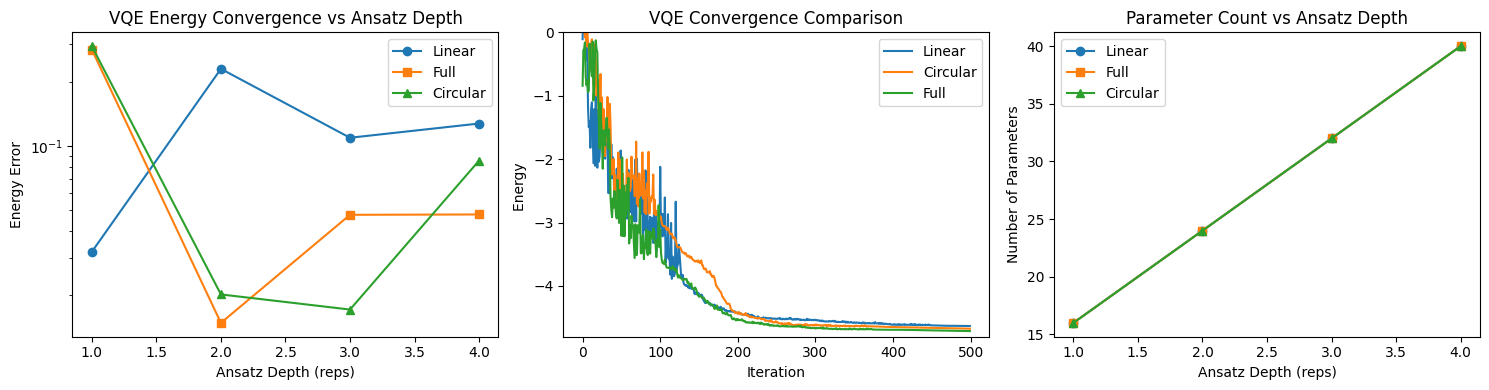

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 1st subplot(depths vs errors)
axes[0].plot(depths, linear_errors, marker="o", label="Linear")
axes[0].plot(depths, full_errors, marker="s", label="Full")
axes[0].plot(depths, circular_errors, marker="^", label="Circular")
axes[0].set_yscale("log")
axes[0].set_title("VQE Energy Convergence vs Ansatz Depth")
axes[0].set_xlabel("Ansatz Depth (reps)")
axes[0].set_ylabel("Energy Error")
axes[0].legend()
# 2nd subplot(convergence vs different type of entanglement )
axes[1].plot(eng_list_lr, label="Linear")
axes[1].plot(eng_list_cl, label="Circular")
axes[1].plot(eng_list_fl, label="Full")
axes[1].set_title("VQE Convergence Comparison")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Energy ")
axes[1].set_ylim(-4.8,0)
axes[1].legend()
#3rd subplot (parameters count vs different type of entanglement)
axes[2].plot(depths, param_counts_linear, marker="o", label="Linear")
axes[2].plot(depths, param_counts_full, marker="s", label="Full")
axes[2].plot(depths, param_counts_circular, marker="^", label="Circular")
axes[2].set_title("Parameter Count vs Ansatz Depth")
axes[2].set_xlabel("Ansatz Depth (reps)")
axes[2].set_ylabel("Number of Parameters")
axes[2].legend()
plt.tight_layout()
plt.show()

In [28]:
#Inferences
#General beleif increasing depth to reduce energy gap isnt working!!
#here also linear shows better results
#Parameter count stays constant

In [29]:
n = 4
J = 1
d=5
entanglement='linear'
h_values = np.linspace(2,3,10)
E0_class=[]
E1_class=[]
E0_quantum=[]
E1_quantum=[]
gaps_classical = []
gaps_quantum = []
gaps_error = []
for h in h_values:
    H = build_tfim(n, J, h)
    E0_Classical, E1_classical = exact_n_energy(H,0),exact_n_energy(H,1)
    E0_class.append(E0_Classical)
    E1_class.append(E1_classical)
    gap_c = E1_classical - E0_Classical
    gaps_classical.append(gap_c)
    eq,E0 = VQE_ground_energy(H,n,d,entanglement)
    E1 = VQD_excited_n_energy(H, n,2,d,entanglement)
    E0_quantum.append(E0)
    E1_quantum.append(E1)
    gaps_quantum.append(E1 - E0)
    gaps_error.append(np.abs(E1 - E0 - gap_c))
    print(f"h={h:.2f} | Classical:gap={gap_c:.4f};Ground={E0_Classical:.4f};excited={E1_classical:.4f} | Quantum:gap={E1-E0:.4f};Ground={E0:.4f};excited={E1:.4f}")

h=2.00 | Classical:gap=2.5110;Ground=-8.3768;excited=-5.8658 | Quantum:gap=2.7204;Ground=-8.2810;excited=-5.5606
h=2.11 | Classical:gap=2.7250;Ground=-8.8013;excited=-6.0762 | Quantum:gap=3.5892;Ground=-8.6853;excited=-5.0961
h=2.22 | Classical:gap=2.9400;Ground=-9.2277;excited=-6.2877 | Quantum:gap=4.1478;Ground=-9.1268;excited=-4.9790
h=2.33 | Classical:gap=3.1558;Ground=-9.6559;excited=-6.5001 | Quantum:gap=4.7628;Ground=-9.5523;excited=-4.7896
h=2.44 | Classical:gap=3.3723;Ground=-10.0856;excited=-6.7133 | Quantum:gap=4.3602;Ground=-9.9477;excited=-5.5875
h=2.56 | Classical:gap=3.5894;Ground=-10.5166;excited=-6.9272 | Quantum:gap=4.2873;Ground=-10.4094;excited=-6.1222
h=2.67 | Classical:gap=3.8069;Ground=-10.9487;excited=-7.1418 | Quantum:gap=4.0077;Ground=-10.8032;excited=-6.7955
h=2.78 | Classical:gap=4.0249;Ground=-11.3818;excited=-7.3569 | Quantum:gap=4.8787;Ground=-11.3189;excited=-6.4402
h=2.89 | Classical:gap=4.2433;Ground=-11.8158;excited=-7.5725 | Quantum:gap=5.1836;Ground

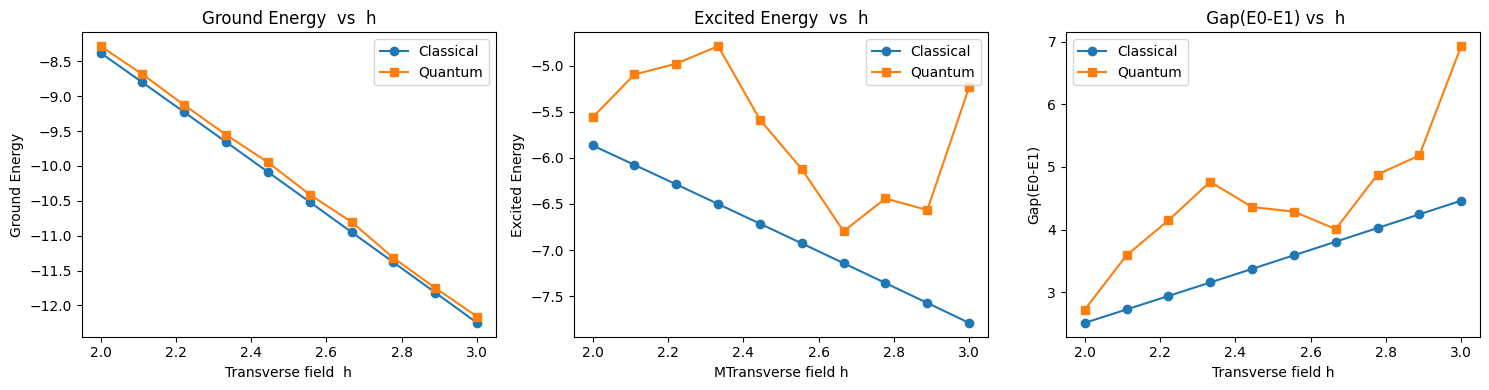

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 1st subplot( Ground energy  vs h)
axes[0].plot(h_values, E0_class, marker="o", label="Classical")
axes[0].plot(h_values, E0_quantum, marker="s", label="Quantum")
axes[0].set_title("Ground Energy  vs  h")
axes[0].set_xlabel("Transverse field  h")
axes[0].set_ylabel("Ground Energy")
axes[0].legend()
# 2nd subplot(Excited energy vs h)
axes[1].plot(h_values, E1_class, marker="o", label="Classical")
axes[1].plot(h_values, E1_quantum, marker="s", label="Quantum")
axes[1].set_title("Excited Energy  vs  h")
axes[1].set_xlabel("MTransverse field h")
axes[1].set_ylabel("Excited Energy")
axes[1].legend()
# 3rd subplot(Energy gap  vs h)
axes[2].plot(h_values,gaps_classical, marker="o", label="Classical")
axes[2].plot(h_values,gaps_quantum, marker="s", label="Quantum")
axes[2].set_title(" Gap(E0-E1) vs  h")
axes[2].set_xlabel("Transverse field h")
axes[2].set_ylabel("Gap(E0-E1)")
axes[2].legend()
plt.tight_layout()
plt.show()

In [31]:
#VQD is performing soo bad !!
#what the heck this,I changed intializer ,increased depth, changed betas but no improvement in results,
#I am getting very bad results for excited state energy, even the gap error is huge,
#I am not sure what is going wrong here, I will try to debug this later, 
#I add ssvqe results for comparison, but still no improvement in results, I am getting very bad results for excited state energy, even the gap error is huge, I am not sure what is going wrong here, I will try to debug this later,


In [32]:
def SSVQE_energies(H, n, reps=4, entanglement="full", runs=15):
    ansatz = tfim_ansatz(n, reps=reps, entanglement=entanglement)
    def basis_state(i):
        state = np.zeros(2**n)
        if i == 0:
            state[0] = 1
        elif i == 1:
            state[2**(n-1)] = 1
        return Statevector(state)
    best_cost = 1e10
    best_theta = None
    for _ in range(runs):
        theta0 = np.random.random(ansatz.num_parameters)
        def cost(theta):
            U = ansatz.assign_parameters(theta)
            weights = [1,5]
            total_energy = 0
            for i in range(2):
                psi = basis_state(i).evolve(U)
                energy = np.real(psi.expectation_value(H))
                total_energy += weights[i]*energy
            return total_energy
        result = minimize(
            cost,
            theta0,
            method="COBYLA",
            options={"maxiter":200}
        )
        if result.fun < best_cost:
            best_cost = result.fun
            best_theta = result.x
    U = ansatz.assign_parameters(best_theta)
    energies = []
    for i in range(2):
        psi = basis_state(i).evolve(U)
        energy = np.real(psi.expectation_value(H))
        energies.append(energy)
    E0, E1 = energies
    return E0, E1, E1 - E0

In [34]:
n = 4
J = 1
d=3
entanglement='linear'
h_values = np.linspace(2,3,10)
E0_class=[]
E1_class=[]
E0_quantum=[]
E1_quantum=[]
gaps_classical = []
gaps_quantum = []
gaps_error = []
for h in h_values:
    H = build_tfim(n, J, h)
    E0_Classical, E1_classical = exact_n_energy(H,0),exact_n_energy(H,1)
    E0_class.append(E0_Classical)
    E1_class.append(E1_classical)
    gap_c = E1_classical - E0_Classical
    gaps_classical.append(gap_c)
    E0, E1, gap = SSVQE_energies(H, n, reps=d, entanglement=entanglement)
    eq,E0_q=VQE_ground_energy(H,n,d,entanglement)
    E0_quantum.append(E0_q)
    E1_quantum.append(E1) 
    gaps_quantum.append(E1 - E0_q)
    gaps_error.append(np.abs(E1 - E0_q - gap_c))
    print(f"h={h:.2f} | Classical:gap={gap_c:.4f};Ground={E0_Classical:.4f};excited={E1_classical:.4f} | Quantum:gap={E1-E0_q:.4f};Ground={E0_q:.4f};excited={E1:.4f}")

h=2.00 | Classical:gap=2.5110;Ground=-8.3768;excited=-5.8658 | Quantum:gap=0.1240;Ground=-8.3326;excited=-8.2086
h=2.11 | Classical:gap=2.7250;Ground=-8.8013;excited=-6.0762 | Quantum:gap=0.1422;Ground=-8.7835;excited=-8.6413
h=2.22 | Classical:gap=2.9400;Ground=-9.2277;excited=-6.2877 | Quantum:gap=0.1736;Ground=-9.2009;excited=-9.0273
h=2.33 | Classical:gap=3.1558;Ground=-9.6559;excited=-6.5001 | Quantum:gap=-0.0136;Ground=-9.5467;excited=-9.5603
h=2.44 | Classical:gap=3.3723;Ground=-10.0856;excited=-6.7133 | Quantum:gap=0.0001;Ground=-9.9585;excited=-9.9584
h=2.56 | Classical:gap=3.5894;Ground=-10.5166;excited=-6.9272 | Quantum:gap=0.0218;Ground=-10.3821;excited=-10.3604
h=2.67 | Classical:gap=3.8069;Ground=-10.9487;excited=-7.1418 | Quantum:gap=0.1238;Ground=-10.9382;excited=-10.8143
h=2.78 | Classical:gap=4.0249;Ground=-11.3818;excited=-7.3569 | Quantum:gap=0.1268;Ground=-11.2993;excited=-11.1724
h=2.89 | Classical:gap=4.2433;Ground=-11.8158;excited=-7.5725 | Quantum:gap=0.1288;Gr

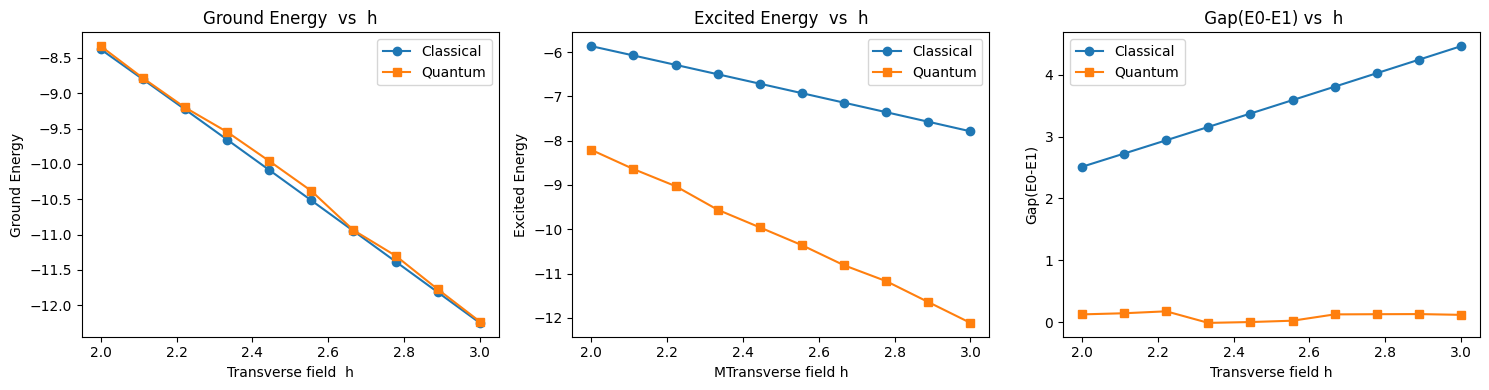

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 1st subplot( Ground energy  vs h)
axes[0].plot(h_values, E0_class, marker="o", label="Classical")
axes[0].plot(h_values, E0_quantum, marker="s", label="Quantum")
axes[0].set_title("Ground Energy  vs  h")
axes[0].set_xlabel("Transverse field  h")
axes[0].set_ylabel("Ground Energy")
axes[0].legend()
# 2nd subplot(Excited energy vs h)
axes[1].plot(h_values, E1_class, marker="o", label="Classical")
axes[1].plot(h_values, E1_quantum, marker="s", label="Quantum")
axes[1].set_title("Excited Energy  vs  h")
axes[1].set_xlabel("MTransverse field h")
axes[1].set_ylabel("Excited Energy")
axes[1].legend()
# 3rd subplot(Energy gap  vs h)
axes[2].plot(h_values,gaps_classical, marker="o", label="Classical")
axes[2].plot(h_values,gaps_quantum, marker="s", label="Quantum")
axes[2].set_title(" Gap(E0-E1) vs  h")
axes[2].set_xlabel("Transverse field h")
axes[2].set_ylabel("Gap(E0-E1)")
axes[2].legend()
plt.tight_layout()
plt.show()

In [36]:
# Too bad so i am gonna choose a new method called Quantum subspace expansion

In [37]:
def QSE_energies(H, psi0, n):
    ops = []
    ops.append(SparsePauliOp.from_list([("I"*n,1)]))
    for i in range(n):
        p = ["I"]*n
        p[i] = "X"
        ops.append(SparsePauliOp.from_list([("".join(p),1)]))
    for i in range(n):
        p = ["I"]*n
        p[i] = "Z"
        ops.append(SparsePauliOp.from_list([("".join(p),1)]))
    dim = len(ops)
    Hmat = np.zeros((dim,dim))
    Smat = np.zeros((dim,dim))
    for i in range(dim):
        for j in range(dim):
            psi_i = psi0.evolve(ops[i])
            psi_j = psi0.evolve(ops[j])
            Hmat[i,j] = np.real(
                np.vdot(psi_i.data, psi_j.evolve(H).data)
            )
            Smat[i,j] = np.real(
                np.vdot(psi_i.data, psi_j.data)
            )
    energies,_ = eigh(Hmat,Smat)

    energies = np.sort(energies)

    return energies

In [6]:
def VQE_ground_energy(H, n, reps, entanglement):
    ansatz = tfim_ansatz(n, reps=reps, entanglement=entanglement)
    optimizer = COBYLA(maxiter=500)
    estimator = StatevectorEstimator()
    vqe = VQE(
        estimator=estimator,
        ansatz=ansatz,
        optimizer=optimizer
    )
    result = vqe.compute_minimum_eigenvalue(H)
    optimal_params = result.optimal_point
    ground_energy = result.eigenvalue.real
    psi0 = Statevector.from_label("0"*n).evolve(
        ansatz.assign_parameters(optimal_params)
    )
    return psi0, optimal_params, ground_energy

In [39]:
n = 4
J = 1
d=3
entanglement='linear'
h_values = np.linspace(2,3,10)
E0_class=[]
E1_class=[]
E0_quantum=[]
E1_quantum=[]
gaps_classical = []
gaps_quantum = []
gaps_error = []
for h in h_values:
    H = build_tfim(n, J, h)
    E0_Classical, E1_classical = exact_n_energy(H,0),exact_n_energy(H,1)
    E0_class.append(E0_Classical)
    E1_class.append(E1_classical)
    gap_c = E1_classical - E0_Classical
    gaps_classical.append(gap_c)
    psi0,eq,E0_q=VQE_ground_energy(H,n,d,entanglement)
    E1_q=QSE_energies(H,psi0,n)[1]
    E0_quantum.append(E0_q)
    E1_quantum.append(E1_q)
    gaps_quantum.append(E1_q - E0_q)
    gaps_error.append(np.abs(E1_q - E0_q - gap_c))
    print(f"h={h:.2f} | Classical:gap={gap_c:.4f};Ground={E0_Classical:.4f};excited={E1_classical:.4f} | Quantum:gap={E1_q-E0_q:.4f};Ground={E0_q:.4f};excited={E1_q:.4f}")

h=2.00 | Classical:gap=2.5110;Ground=-8.3768;excited=-5.8658 | Quantum:gap=2.4287;Ground=-8.1990;excited=-5.7703
h=2.11 | Classical:gap=2.7250;Ground=-8.8013;excited=-6.0762 | Quantum:gap=2.7110;Ground=-8.7476;excited=-6.0365
h=2.22 | Classical:gap=2.9400;Ground=-9.2277;excited=-6.2877 | Quantum:gap=2.8926;Ground=-9.1532;excited=-6.2607
h=2.33 | Classical:gap=3.1558;Ground=-9.6559;excited=-6.5001 | Quantum:gap=3.1377;Ground=-9.6197;excited=-6.4819
h=2.44 | Classical:gap=3.3723;Ground=-10.0856;excited=-6.7133 | Quantum:gap=3.3306;Ground=-10.0011;excited=-6.6705
h=2.56 | Classical:gap=3.5894;Ground=-10.5166;excited=-6.9272 | Quantum:gap=3.5671;Ground=-10.4808;excited=-6.9138
h=2.67 | Classical:gap=3.8069;Ground=-10.9487;excited=-7.1418 | Quantum:gap=3.7922;Ground=-10.9280;excited=-7.1358
h=2.78 | Classical:gap=4.0249;Ground=-11.3818;excited=-7.3569 | Quantum:gap=3.9877;Ground=-11.3054;excited=-7.3178
h=2.89 | Classical:gap=4.2433;Ground=-11.8158;excited=-7.5725 | Quantum:gap=4.1845;Groun

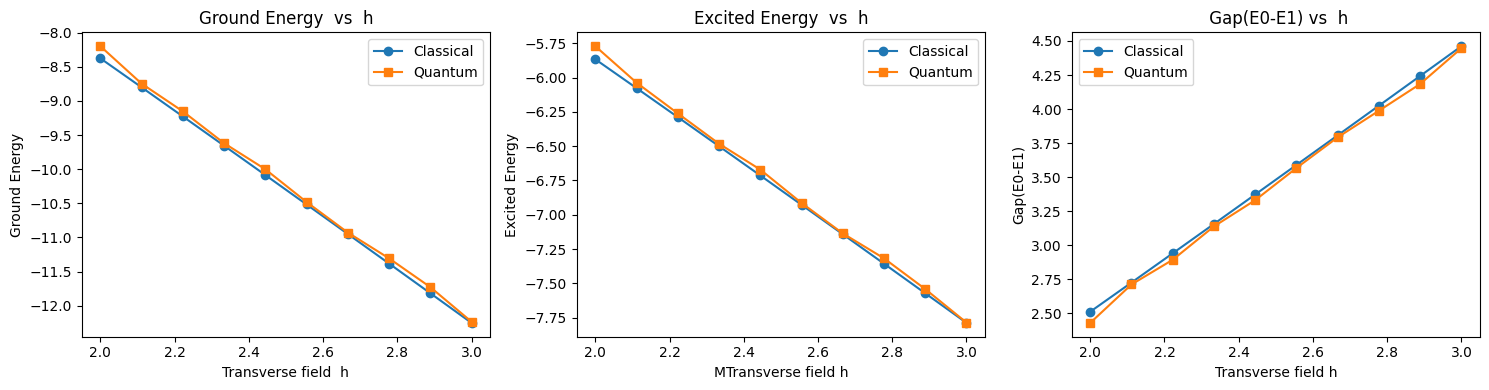

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 1st subplot( Ground energy  vs h)
axes[0].plot(h_values, E0_class, marker="o", label="Classical")
axes[0].plot(h_values, E0_quantum, marker="s", label="Quantum")
axes[0].set_title("Ground Energy  vs  h")
axes[0].set_xlabel("Transverse field  h")
axes[0].set_ylabel("Ground Energy")
axes[0].legend()
# 2nd subplot(Excited energy vs h)
axes[1].plot(h_values, E1_class, marker="o", label="Classical")
axes[1].plot(h_values, E1_quantum, marker="s", label="Quantum")
axes[1].set_title("Excited Energy  vs  h")
axes[1].set_xlabel("MTransverse field h")
axes[1].set_ylabel("Excited Energy")
axes[1].legend()
# 3rd subplot(Energy gap  vs h)
axes[2].plot(h_values,gaps_classical, marker="o", label="Classical")
axes[2].plot(h_values,gaps_quantum, marker="s", label="Quantum")
axes[2].set_title(" Gap(E0-E1) vs  h")
axes[2].set_xlabel("Transverse field h")
axes[2].set_ylabel("Gap(E0-E1)")
axes[2].legend()
plt.tight_layout()
plt.show()

In [4]:
def entanglement_entropy(statevector, n, cut=None):   
    if cut is None:
        cut = n//2   
    psi = statevector.data
    psi_matrix = psi.reshape(2**cut, 2**(n-cut))
    rhoA = psi_matrix @ psi_matrix.conj().T
    eigvals = np.linalg.eigvalsh(rhoA)
    eigvals = eigvals[eigvals > 1e-12]
    S = -np.sum(eigvals * np.log(eigvals))
    return S

In [7]:
J=1
d=3
n=10
entanglement='linear'
h_values =np.linspace(0,2,20)
entropies = []
for h in h_values:
    H=build_tfim(n,J,h)
    psi0,_, E0 = VQE_ground_energy(H, n, d, entanglement)
    S = entanglement_entropy(psi0, n)
    entropies.append(S)

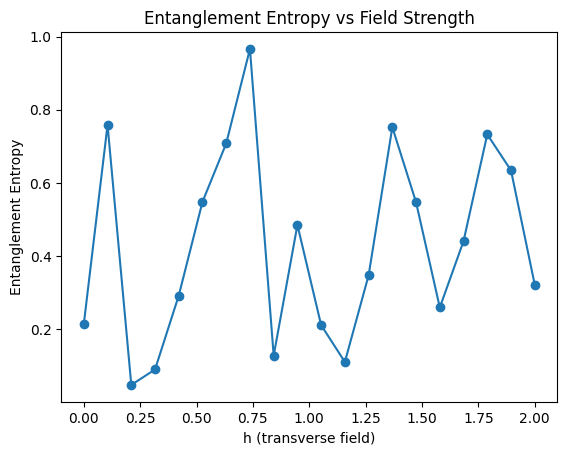

In [45]:
plt.plot(h_values, entropies, marker='o')
plt.xlabel("h (transverse field)")
plt.ylabel("Entanglement Entropy")
plt.title("Entanglement Entropy vs Field Strength")
plt.show()

In [12]:
J=1
d=3
n=[4,6,8,10,12,14,16,18,20]
h=1
entanglement='linear'
entropies = []
for i in n:
    H=build_tfim(i,J,h)
    psi0,_,E0=VQE_ground_energy(H, i, d, entanglement)
    S=entanglement_entropy(psi0, i)
    entropies.append(S)

In [1]:
plt.plot(n, entropies, marker='o')
plt.xlabel("n (number of qubits)")
plt.ylabel("Entanglement Entropy")
plt.title("Entanglement Entropy vs Number of Qubits")
plt.show()

NameError: name 'plt' is not defined